In [21]:
import numpy as np
import matplotlib.pyplot as plt

### Global Variables

In [22]:
sigma_detectorresolution_inner_rphi = 5 * 10**-6   #spatial resolution of the ITS2 inner layers in rphi in meters
sigma_detectorresolution_inner_z = 5 * 10**-6      #spatial resolution of the ITS2 inner layers in z    in meters

sigma_detectorresolution_outer_rphi = 10 * 10**-6   #spatial resolution of the ITS2 outer layers in rphi in meters
sigma_detectorresolution_outer_z = 10 * 10**-6      #spatial resolution of the ITS2 outer layers in z    in meters

layerthickness_inner = 0.0035  # thickness of an inner detector plane in units of radiation length 0.35%
layerthickness_outer = 0.008   # thickness of an outer detector plane in units of radiation length 0.8%

average_layer_radii = np.array([23, 31, 39, 196, 245, 344, 393]) * 10**-3   # average radius of ITS2 layers in meters

magnetic_field_strength = 0.5           # strength of magnetic field in Alice in Tesla

particle_momentum = 1           # momentum of particle in GeV/c
particle_mass = 1               # mass of particle in GeV/c^2

#particle_energy = np.sqrt(particle_momentum**2 + particle_mass**2)  # energy of particle in GeV
#particle_beta = particle_momentum / particle_energy  # velocity of particle in units of speed of light c 

In [23]:
def RMS_ScatteringAngle(momentum, mass, layerthickness):             # calculates the variance of the scattering angle of a particle with given momentum and mass and given layer thickness
    energy = np.sqrt(momentum**2 + mass**2)
    beta = momentum / energy
    f = 0.013 * np.sqrt(layerthickness) * (1 + 0.038*np.log(layerthickness))
    return 1/(beta*momentum) * f 

sigma_ScatteringAngle_inner = RMS_ScatteringAngle(particle_momentum, particle_mass, layerthickness_inner)  # variance of scattering angle inner layer
sigma_ScatteringAngle_outer = RMS_ScatteringAngle(particle_momentum, particle_mass, layerthickness_outer)  # variance of scattering angle outer layer


#### Straight Line 
- equidistant N+1 layers
- with identical thickness
- without MS in air

In [24]:
N = 3                # Number of layers - 1
L = average_layer_radii[6] - average_layer_radii[3]    # Length over which detector layers are distributed in meters
r = np.array([0.025, 0.125])  # extrapolation length in meters (is defined away from layers) ;

# contribution from detector resolution

posreso_det_straight_form = np.sqrt(4*sigma_detectorresolution_outer_rphi**2 / ((N+1)*(N+2)) * ((N+0.5) + 3*N*r/L + 3*N*r**2/L**2))   # sqrt of variance of track position after extrapolation with distrance r

# contribution from multiple scattering

posreso_MS_straight_form = r * sigma_ScatteringAngle_outer  #  for straight line effects of more layers and more MS cancels

print("contribution from detector resolution", posreso_det_straight_form)
print("contribution from multiple scattering" , posreso_MS_straight_form)


contribution from detector resolution [9.78475609e-06 1.60213452e-05]
contribution from multiple scattering [3.35669861e-05 1.67834930e-04]


#### Parabolic track
- equidistant N+1 layers
- with identical thickness
- without MS in air
- approximated with polynomial of second order f(x) =  a0 + a1*x + a2/2 * x^2

In [25]:
# contribution from detector resolution

momentumreso_det_parabolic_form = sigma_detectorresolution_outer_rphi * particle_momentum / (0.3 * magnetic_field_strength * L**2) * np.sqrt(720*N**3 / ((N-1)*(N+1)*(N+2)*(N+3)))     # momentum resolution 
posreso_det_parabolic_form = 3 * sigma_detectorresolution_outer_rphi / np.sqrt((N-1)*(N+1)*(N+2)*(N+3)) * np.sqrt((N**3 - N/3 - 2/3)   +   4*(2*N**3 - N**2 - N)*r /L   +   4*(7*N**3 - N**2 - N)*r**2 /L**2   +   40*N**3*r**3 /L**3   +   20*N**3*r**4 /L**4)    #  position resolution after extrapolation with distrance r

# contribution from multiple scattering

momentumreso_MS_parabolic_form = N / np.sqrt((N+1)*(N-1)) * particle_momentum * sigma_ScatteringAngle_outer * np.sqrt(N+1) / (0.3 * magnetic_field_strength * L)    # momentum resolution
posreso_MS_parabolic_form = sigma_ScatteringAngle_outer * r * np.sqrt((N-0.75)/(N-1) + N*r/(2*(N-1)*L) + N**2*r**2/(4*(N-1)*L**2))    #  position resolution after extrapolation with distrance r

print("Momentum Resolution:")
print("contribution from detector resolution", momentumreso_det_parabolic_form)
print("contribution from multiple scattering" , momentumreso_MS_parabolic_form)
print()
print("Position Resolution:")
print("contribution from detector resolution", posreso_det_parabolic_form)
print("contribution from multiple scattering" , posreso_MS_parabolic_form)


Momentum Resolution:
contribution from detector resolution 0.015460331366435619
contribution from multiple scattering 0.09638758768424399

Position Resolution:
contribution from detector resolution [1.50502152e-05 5.40977158e-05]
contribution from multiple scattering [3.73529107e-05 2.40527290e-04]


####  Self test of straight and parabolic trackmodel
- equidistant N+1 layers
- with identical thickness
- without MS in air

In [26]:
N = 3                # Number of layers - 1
L = average_layer_radii[6] - average_layer_radii[3]    # Length over which detector layers are distributed in meters
r = np.array([0.025, 0.125])  # extrapolation length in meters (is defined away from layers) ;

example_layer_positions = np.array([0, L/N, 2*L/N, 3*L/N])    # example layer positons (later real ITS2 positions)

cov_det = np.identity(N+1) * sigma_detectorresolution_outer_rphi**2      # the covariance matrix for detector resolution
cov_MS = np.zeros((N+1, N+1))                                              # the covariance matrix multiple scattering
for m in range(N+1):
    for n in range(N+1):
        sum = 0      
        for j in range(np.min(np.array([m,n]))):
            sum += sigma_ScatteringAngle_outer**2 * (example_layer_positions[m] - example_layer_positions[j]) * (example_layer_positions[n] - example_layer_positions[j])
        cov_MS[m][n] = sum
cov_MS[0][0] = 10**-50       #  to avoid singular matrix

print(cov_det)
print(cov_MS)
print(cov_MS * N**2 / (L**2 * sigma_ScatteringAngle_outer**2))

[[1.e-10 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e-10 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e-10 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e-10]]
[[1.00000000e-50 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 7.77382253e-09 1.55476451e-08 2.33214676e-08]
 [0.00000000e+00 1.55476451e-08 3.88691127e-08 6.21905803e-08]
 [0.00000000e+00 2.33214676e-08 6.21905803e-08 1.08833515e-07]]
[[1.28636844e-42 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 2.00000000e+00 3.00000000e+00]
 [0.00000000e+00 2.00000000e+00 5.00000000e+00 8.00000000e+00]
 [0.00000000e+00 3.00000000e+00 8.00000000e+00 1.40000000e+01]]


In [27]:
def g0(x):               #  trackmodel helper functions 
    return x**0     
def g1(x):
    return x**1
def g2(x):
    return x**2 /2

trackmodel_straight = np.array([g0, g1])     #  straight track model f(x) = a0*g0(x) + a1*g1(x)
trackmodel_parabolic = np.array([g0, g1, g2])    #  parabolic track model f(x) = a0*g0(x) + a1*g1(x) + a2/2 * g2(x)

def get_trackmodel_matrix(layer_positions, trackmodel):   # trackmodel matrix G helper function
    trackmodel_list = []
    for f in trackmodel:
        trackmodel_list.append(f(layer_positions))
    return np.stack(trackmodel_list)

trackmodel_matrix_straight = get_trackmodel_matrix(example_layer_positions, trackmodel_straight)  # straight trackmodel matrix
print(trackmodel_matrix_straight)

trackmodel_matrix_parabolic = get_trackmodel_matrix(example_layer_positions, trackmodel_parabolic)   # parabolic trackmodel matrix
print(trackmodel_matrix_parabolic)

[[1.         1.         1.         1.        ]
 [0.         0.06566667 0.13133333 0.197     ]]
[[1.         1.         1.         1.        ]
 [0.         0.06566667 0.13133333 0.197     ]
 [0.         0.00215606 0.00862422 0.0194045 ]]


In [28]:
# straight track model
cov_para_det_straight = np.linalg.inv(trackmodel_matrix_straight @ np.linalg.inv(cov_det) @ trackmodel_matrix_straight.T)   #  C_a contribution from detector resolution
cov_para_MS_straight = np.linalg.inv(trackmodel_matrix_straight @ np.linalg.inv(cov_MS) @ trackmodel_matrix_straight.T)     #  C_a contribution from MS

# parabolic track model
cov_para_det_parabolic = np.linalg.inv(trackmodel_matrix_parabolic @ np.linalg.inv(cov_det) @ trackmodel_matrix_parabolic.T)   #  C_a contribution from detector resolution
cov_para_MS_parabolic = np.linalg.inv(trackmodel_matrix_parabolic @ np.linalg.inv(cov_MS) @ trackmodel_matrix_parabolic.T)        #  C_a contribution from MS

apply = np.vectorize(lambda f, x: f(x), otypes=[object])    # helper function to apply array of functions on one argument


# straight track model
posreso_det_straight = np.array([np.sqrt(apply(trackmodel_straight, -r[0]).T @ cov_para_det_straight @ apply(trackmodel_straight, -r[0])), np.sqrt(apply(trackmodel_straight, -r[1]).T @ cov_para_det_straight @ apply(trackmodel_straight, -r[1]))])
posreso_MS_straight = np.array([np.sqrt(apply(trackmodel_straight, -r[0]).T @ cov_para_MS_straight @ apply(trackmodel_straight, -r[0])), np.sqrt(apply(trackmodel_straight, -r[1]).T @ cov_para_MS_straight @ apply(trackmodel_straight, -r[1]))])
print("contribution from detector resolution", posreso_det_straight)
print("contribution from multiple scattering", posreso_MS_straight)

contribution from detector resolution [9.78475609e-06 1.60213452e-05]
contribution from multiple scattering [3.35669861e-05 1.67834930e-04]


In [29]:
# parabolic track model
posreso_det_parabolic = np.array([np.sqrt(apply(trackmodel_parabolic, -r[0]).T @ cov_para_det_parabolic @ apply(trackmodel_parabolic, -r[0])), np.sqrt(apply(trackmodel_parabolic, -r[1]).T @ cov_para_det_parabolic @ apply(trackmodel_parabolic, -r[1]))])
posreso_MS_parabolic = np.array([np.sqrt(apply(trackmodel_parabolic, -r[0]).T @ cov_para_MS_parabolic @ apply(trackmodel_parabolic, -r[0])), np.sqrt(apply(trackmodel_parabolic, -r[1]).T @ cov_para_MS_parabolic @ apply(trackmodel_parabolic, -r[1]))])
print("Position Resolution:")
print("contribution from detector resolution", posreso_det_parabolic)
print("contribution from multiple scattering", posreso_MS_parabolic)

momentumreso_det_parabolic = particle_momentum / (0.3*magnetic_field_strength) * np.sqrt(cov_para_det_parabolic[2][2])
momentumreso_MS_parabolic = particle_momentum / (0.3*magnetic_field_strength) * np.sqrt(cov_para_MS_parabolic[2][2])
print()
print("Momentum Resolution:")
print("contribution from detector resolution", momentumreso_det_parabolic)
print("contribution from multiple scattering" , momentumreso_MS_parabolic)

Position Resolution:
contribution from detector resolution [1.50502152e-05 5.40977158e-05]
contribution from multiple scattering [3.73529107e-05 2.40527290e-04]

Momentum Resolution:
contribution from detector resolution 0.015460331366435627
contribution from multiple scattering 0.09638758768424407


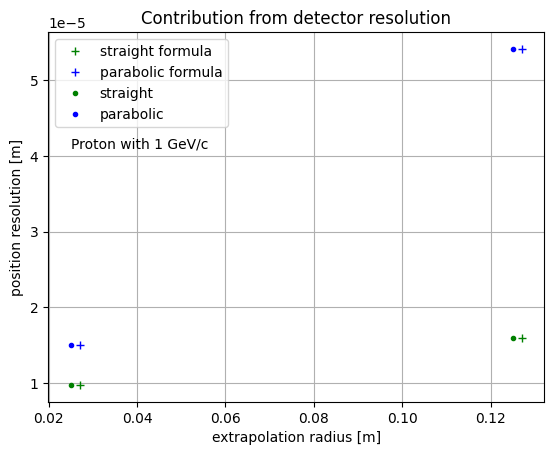

In [30]:
plt.plot(r+0.002, posreso_det_straight_form, "+", color = "green", label = "straight formula")
plt.plot(r+0.002, posreso_det_parabolic_form, "+", color = "blue", label = "parabolic formula")
plt.plot(r, posreso_det_straight, ".", color = "green", label = "straight")
plt.plot(r, posreso_det_parabolic, ".", color = "blue", label = "parabolic")
plt.plot()
plt.xlabel("extrapolation radius [m]")
plt.ylabel("position resolution [m]")
plt.title("Contribution from detector resolution")
plt.text(0.025, 4.1*10**-5, "Proton with 1 GeV/c")
plt.grid()
plt.legend()

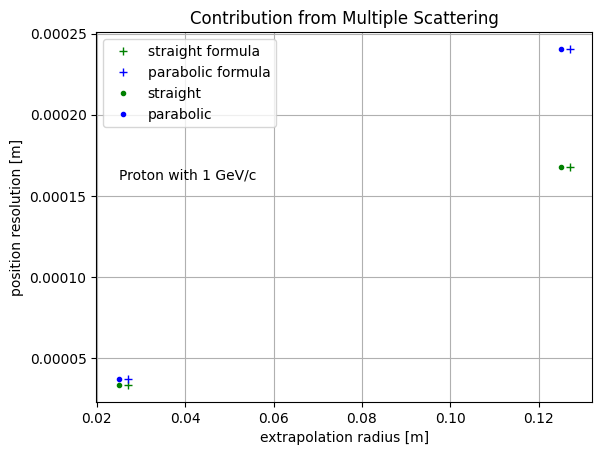

In [31]:
plt.plot(r+0.002, posreso_MS_straight_form, "+", color = "green", label = "straight formula")
plt.plot(r+0.002, posreso_MS_parabolic_form, "+", color = "blue", label = "parabolic formula")
plt.plot(r, posreso_MS_straight, ".", color = "green", label = "straight")
plt.plot(r, posreso_MS_parabolic, ".", color = "blue", label = "parabolic")
plt.plot()
plt.xlabel("extrapolation radius [m]")
plt.ylabel("position resolution [m]")
plt.title("Contribution from Multiple Scattering")
plt.text(0.025, 16*10**-5, "Proton with 1 GeV/c")
plt.grid()
plt.legend()

### Further Tests

In [32]:
posreso_tot_straight_form = np.sqrt(posreso_det_straight_form**2 + posreso_MS_straight_form**2)
print(posreso_tot_straight_form)

posreso_tot_parabolic_form = np.sqrt(posreso_det_parabolic_form**2 + posreso_MS_parabolic_form**2)
print(posreso_tot_parabolic_form)


cov_tot = cov_det + cov_MS
cov_para_tot_straight = np.linalg.inv(trackmodel_matrix_straight @ np.linalg.inv(cov_tot) @ trackmodel_matrix_straight.T)  # straight track model
cov_para_tot_parabolic = np.linalg.inv(trackmodel_matrix_parabolic @ np.linalg.inv(cov_tot) @ trackmodel_matrix_parabolic.T)  # parabolic track model

# straight track model
posreso_tot_straight = np.array([np.sqrt(apply(trackmodel_straight, -r[0]).T @ cov_para_tot_straight @ apply(trackmodel_straight, -r[0])), np.sqrt(apply(trackmodel_straight, -r[1]).T @ cov_para_tot_straight @ apply(trackmodel_straight, -r[1]))])
# parabolic track model
posreso_tot_parabolic = np.array([np.sqrt(apply(trackmodel_parabolic, -r[0]).T @ cov_para_tot_parabolic @ apply(trackmodel_parabolic, -r[0])), np.sqrt(apply(trackmodel_parabolic, -r[1]).T @ cov_para_tot_parabolic @ apply(trackmodel_parabolic, -r[1]))])

print()
print(posreso_tot_straight)
print(posreso_tot_parabolic)

[3.49640387e-05 1.68597886e-04]
[4.02709438e-05 2.46535880e-04]

[3.64184046e-05 1.71222662e-04]
[4.06195209e-05 2.47201691e-04]


# Tests for MS in air

In [33]:
sigma_detectorresolution_inner_rphi = 5 * 10**-6   #spatial resolution of the ITS2 inner layers in rphi in meters
sigma_detectorresolution_inner_z = 5 * 10**-6      #spatial resolution of the ITS2 inner layers in z    in meters

sigma_detectorresolution_outer_rphi = 10 * 10**-6   #spatial resolution of the ITS2 outer layers in rphi in meters
sigma_detectorresolution_outer_z = 10 * 10**-6      #spatial resolution of the ITS2 outer layers in z    in meters

layerthickness_inner = 0.0035  # thickness of an inner detector plane in units of radiation length 0.35%
layerthickness_outer = 0.008   # thickness of an outer detector plane in units of radiation length 0.8%

average_layer_radii = np.array([23, 31, 39, 196, 245, 344, 393]) * 10**-3   # average radius of ITS2 layers in meters

magnetic_field_strength = 0.5           # strength of magnetic field in Alice in Tesla

particle_momentum = 1           # momentum of particle in GeV/c
particle_mass = 1               # mass of particle in GeV/c^2

In [34]:
def get_rms_ScatteringAngle(momentum, mass, layerthickness):             # calculates the variance of the scattering angle of a particle with given momentum and mass and given layer thickness
    energy = np.sqrt(momentum**2 + mass**2)                              # energy of particle in GeV    
    beta = momentum / energy                                             # velocity of particle in units of speed of light c
    f = 0.013 * np.sqrt(layerthickness) * (1 + 0.038*np.log(layerthickness))
    return 1/(beta*momentum) * f 

In [35]:
radiation_length_air = 303.9           # radiation length of air in meters
N = 7                                          # Number of layers with hits
IU_layer = len(average_layer_radii) - N                                              # starts with layer no.0

def get_air_thickness(radiation_length_air, average_layer_radii, IU_layer):    # helper function to calculate the amount of air in between the ITS layers in units of radiation length
    air_thickness = []
    air_thickness.append(10**(-90))                                          # to create 7th entry
    for i in range(len(average_layer_radii)-1):
        air_thickness.append(average_layer_radii[i+1] - average_layer_radii[i])
    air_thickness = np.array(air_thickness) / radiation_length_air
    return air_thickness[IU_layer:]

air_thickness = get_air_thickness(radiation_length_air, average_layer_radii, IU_layer)
print(air_thickness * 100)          # for %

sigma_ScatteringAngle_air = get_rms_ScatteringAngle(particle_momentum, particle_mass, air_thickness)
sigma_ScatteringAngle_air[0] = 0
print(sigma_ScatteringAngle_air)

[3.29055610e-91 2.63244488e-03 2.63244488e-03 5.16617308e-02
 1.61237249e-02 3.25765054e-02 1.61237249e-02]
[0.00000000e+00 5.65294398e-05 5.65294398e-05 2.97695088e-04
 1.55980914e-04 2.30581109e-04 1.55980914e-04]


### Test for OOP implementation wo MS in air 

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from function_library_OOP import DetectorSetup

In [37]:
spatial_resolution_ITS2 = 10 * 10**-6
average_layer_radii_ITS2 = np.array([23, 31, 39, 196, 245, 344, 393]) * 10**-3               # average radius of ITS2 layers in meters
layerthickness_ITS2 = [0.0035, 0.0035, 0.0035, 0.008, 0.008, 0.008, 0.008]               # thickness of the detector planes in units of radiation length 0.35% X0 inner and 1.1% X0 outer
detector_resolutions_rphi_ITS2 = [spatial_resolution_ITS2 for i in range(7)]                 # spatial resolution of the ITS2 layers in rphi in meters
detector_resolutions_z_ITS2 = [spatial_resolution_ITS2 for i in range(7)]                    # spatial resolution of the ITS2  layers in z    in meters
radiation_length_air_ITS2 = 303.9                                                            # radiation length of air in meters
magnetic_field_strength_ITS2 = 0.5                                                           # strength of magnetic field in Alice in Tesla

L = average_layer_radii[6] - average_layer_radii[3]    # Length over which detector layers are distributed in meters
example_layer_positions = np.array([0, 0, 0 ,0, L/3, 2*L/3, 3*L/3])    # example layer positons (later real ITS2 positions)

ITS2 = DetectorSetup(example_layer_positions, layerthickness_ITS2, detector_resolutions_rphi_ITS2, detector_resolutions_z_ITS2, radiation_length_air_ITS2, magnetic_field_strength_ITS2)
ITS2.MS_in_air = False

Detector Setup initialized


In [38]:
proton_mass = 1
proton_momentum = 1
N = 4
r = 0.125
theta = 90

print(ITS2.transverse_track_position_uncertainty(proton_momentum, proton_mass, N, r, theta))
print(ITS2.average_layer_radii)


0.0002465358799295301
[0.         0.06566667 0.13133333 0.197     ]
